# EfficientNetB0 Training for Pneumonia

This notebook trains an **EfficientNetB0** model (transfer learning) to classify chest X‑rays into three classes: **normal**, **bacteria**, **virus**.

## Tooling choices

- **PyTorch**: I use PyTorch because it is widely used in deep learning research, provides fine-grained control over the training loop, and integrates naturally with DataLoaders and advanced transformations (Albumentations).
- **EfficientNetB0 (torchvision)**: EfficientNet is a family of efficient, high-performing image classification networks. The B0 variant is lightweight, which suits a teaching/experimental project while remaining strong enough for simple medical classification.
- **Transfer learning**: we start from a model pretrained on ImageNet (a large natural image dataset) and only replace the final classification layer to learn our 3 pneumonia classes. This usually converges faster and generalizes better on a medium-sized medical dataset.

The data loaders and augmentations are defined in `on_the_fly_augmentation.ipynb` and will be executed here via `%run`. That notebook uses **Albumentations** for “medically safe” transformations and the Hugging Face **datasets** library to load chest X‑rays.

## 1. Loading the augmentation pipeline

In this first step, we **reuse** the `on_the_fly_augmentation.ipynb` notebook:

- it downloads the chest X‑ray dataset,
- applies the Albumentations augmentations,
- builds `train_loader`, `val_loader`, and `test_loader` (PyTorch `DataLoader` objects).

This notebook therefore focuses only on the **model + training** part.

In [ ]:
# Run the on-the-fly augmentation notebook
# This defines: dataset, train_data, val_data, test_data,
# as well as train_loader, val_loader, test_loader

%run "../on_the_fly_augmentation.ipynb"

Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Users\belli\AppData\Local\Programs\Python\Python313\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


DatasetNotFoundError: Dataset 'PAR8/chest-xray-pneumonia' doesn't exist on the Hub or cannot be accessed.

DatasetNotFoundError: Dataset 'PAR8/chest-xray-pneumonia' doesn't exist on the Hub or cannot be accessed.

## 2. Defining EfficientNetB0 and hyperparameters

Here we:

- detect the available **device** (`cuda` if a GPU is available, otherwise `cpu`),
- set a few simple hyperparameters (number of epochs, learning rate, number of classes),
- load an **EfficientNetB0** backbone pretrained on ImageNet from `torchvision`,
- replace the **final classification layer** with a linear layer with 3 outputs (one per class),
- define a loss function (**CrossEntropyLoss**) suited for multiclass classification,
- configure the **Adam** optimizer to update the network weights.

c:\Users\belli\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Users\belli\AppData\Local\Programs\Python\Python313\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
c:\Users\belli\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\belli\.cache\huggingface\hub\datasets--PAR8--chest-xray-pneumonia. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator.


  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


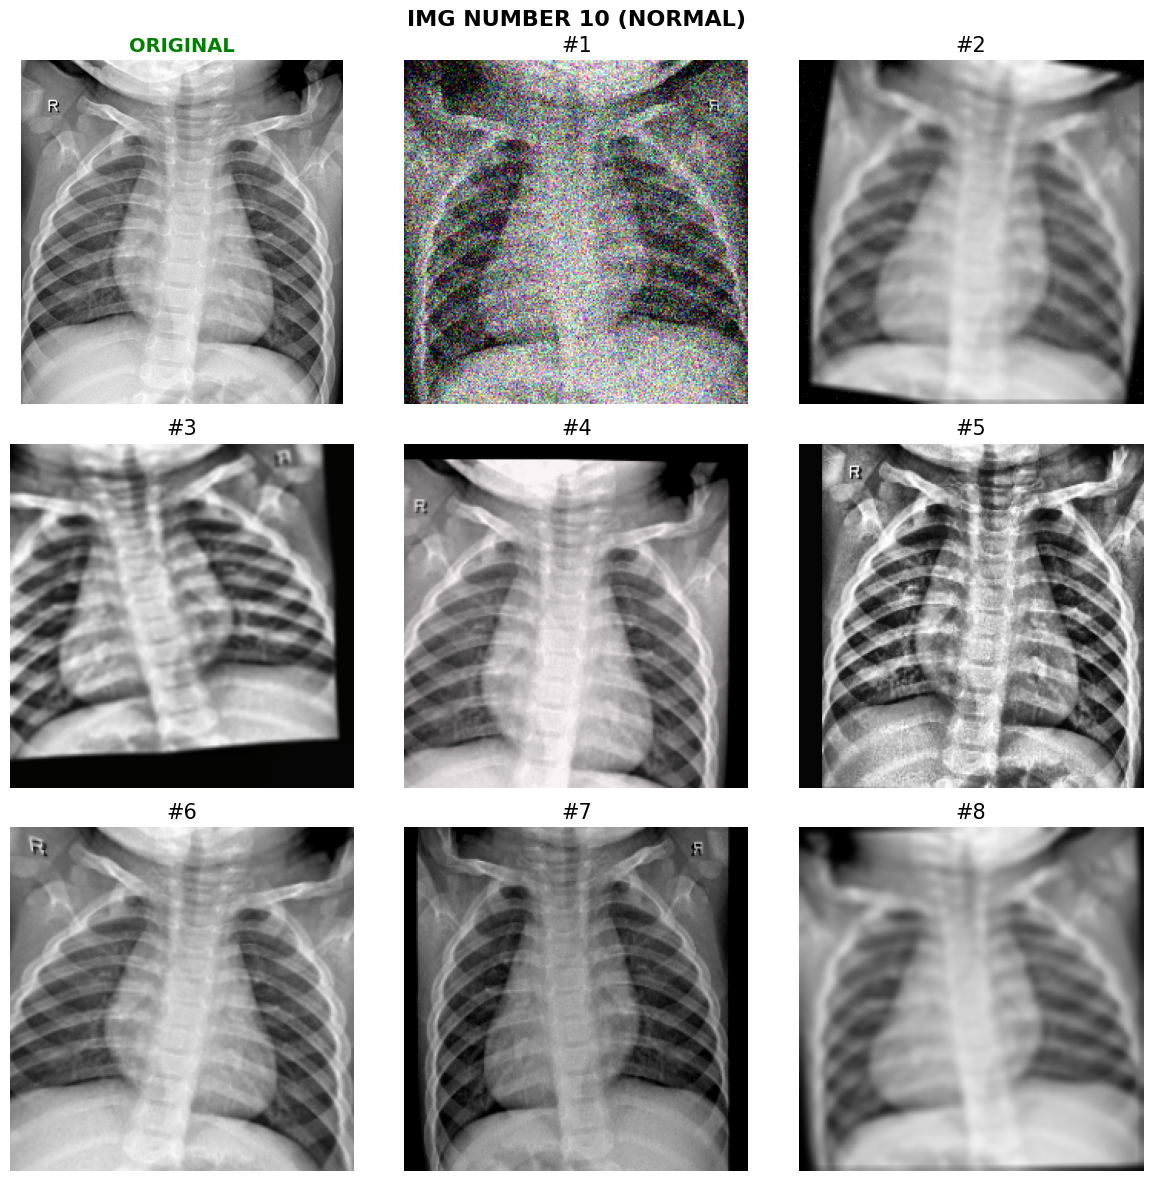


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [1, 1, 2, 1, 0, 1, 0, 1, 1, 2]
Label distribution: [7, 17, 8]


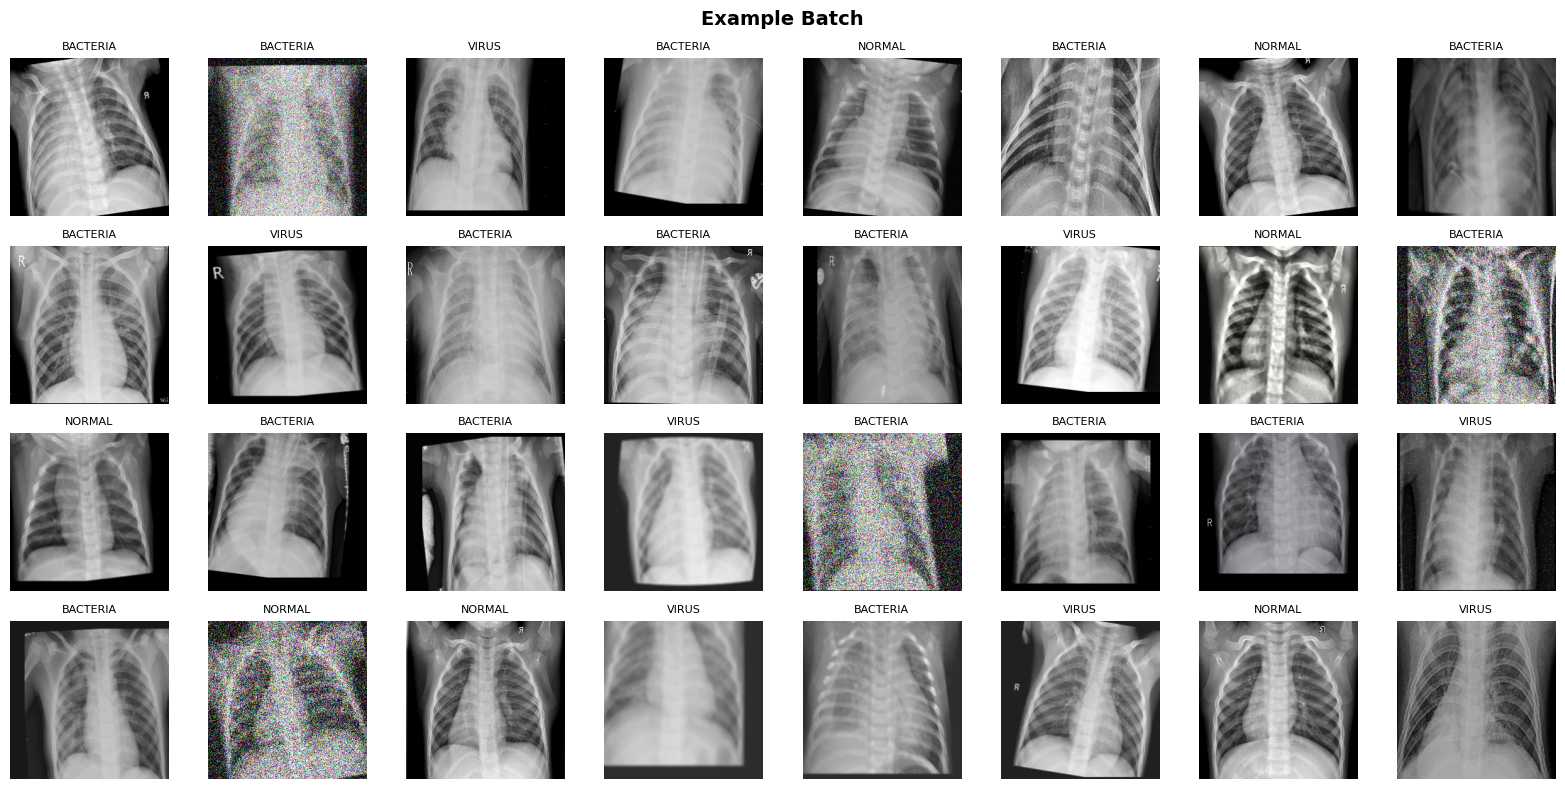

In [2]:
# Run the on-the-fly augmentation notebook
# This defines: dataset, train_data, val_data, test_data,
# as well as train_loader, val_loader, test_loader

%run "../on_the_fly_augmentation.ipynb"

In [4]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Detect device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Training hyperparameters
NUM_CLASSES = 3  # normal, bacteria, virus
learning_rate = 1e-4
num_epochs = 10

# Load EfficientNetB0 backbone pretrained on ImageNet
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)

# Replace the final classification layer
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

# Loss function for multiclass classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer over all model parameters
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("EfficientNetB0 model initialized for 3 classes.")

Using device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\belli/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 58.5MB/s]


EfficientNetB0 model initialized for 3 classes.


## 3. Training and validation loop

We iterate over the training set multiple times (**epochs**) and at each step:

- set the model to `train()` mode to enable weight updates,
- read a batch of images and labels from `train_loader`,
- compute predictions and loss, then run **backward** + `optimizer.step()`,
- aggregate the average training loss over the whole training set.

Then we switch to `eval()` mode for **validation**:

- disable gradients with `torch.no_grad()`,
- compute the validation loss,
- also compute a first simple metric: **accuracy** on the validation set.

Loss/accuracy values per epoch are stored in `train_history` so we can plot them later.

In [5]:
from tqdm.auto import tqdm

train_history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    print(f"\n===== Epoch {epoch}/{num_epochs} =====")

    # --------------------
    # Training phase
    # --------------------
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader, desc="Train", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    # --------------------
    # Validation phase
    # --------------------
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Val", leave=False):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = correct / total if total > 0 else 0.0

    train_history["train_loss"].append(epoch_train_loss)
    train_history["val_loss"].append(epoch_val_loss)
    train_history["val_acc"].append(epoch_val_acc)

    print(f"Train loss: {epoch_train_loss:.4f} | Val loss: {epoch_val_loss:.4f} | Val acc: {epoch_val_acc:.4f}")


===== Epoch 1/10 =====


Train loss: 0.7278 | Val loss: 0.4473 | Val acc: 0.7950

===== Epoch 2/10 =====


Train loss: 0.5762 | Val loss: 0.4200 | Val acc: 0.7931

===== Epoch 3/10 =====


Train loss: 0.5243 | Val loss: 0.3825 | Val acc: 0.8352

===== Epoch 4/10 =====


Train loss: 0.4767 | Val loss: 0.3753 | Val acc: 0.8276

===== Epoch 5/10 =====


...

Train loss: 0.4331 | Val loss: 0.3706 | Val acc: 0.8372

===== Epoch 7/10 =====


Train loss: 0.4094 | Val loss: 0.3620 | Val acc: 0.8352

===== Epoch 8/10 =====


Train loss: 0.3942 | Val loss: 0.3795 | Val acc: 0.8487

===== Epoch 9/10 =====


Train loss: 0.3785 | Val loss: 0.3829 | Val acc: 0.8276

===== Epoch 10/10 =====


Train loss: 0.3610 | Val loss: 0.3877 | Val acc: 0.8314


## 4. Saving the model and plotting curves

At the end of training:

- we **save** the model weights to `efficientnet_b0_pneumonia.pt` (PyTorch format),
- we plot the **loss** curves (train/validation) and **validation accuracy** to quickly check whether the model converges and whether there is overfitting.

Model saved to ./efficientnet_b0_pneumonia.pt


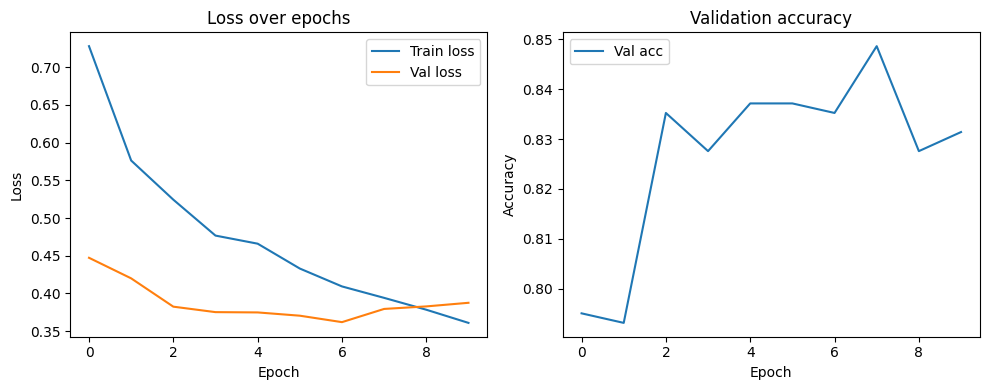

In [6]:
import matplotlib.pyplot as plt

# Save the model
model_path = "./efficientnet_b0_pneumonia.pt"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# Plot loss and accuracy curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_history["train_loss"], label="Train loss")
plt.plot(train_history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over epochs")

plt.subplot(1, 2, 2)
plt.plot(train_history["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation accuracy")

plt.tight_layout()
plt.show()